In [4]:
import pandas as pd

df = pd.read_excel('../data/telco_churn.xlsx')

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [5]:
df.shape


(7043, 33)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [7]:
df.isnull().sum()


CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

In [8]:
df.drop('CustomerID', axis=1, inplace=True)


In [9]:
df.drop(['Lat Long','Latitude','Longitude','Zip Code'], axis=1, inplace=True)


In [10]:
df.drop('Churn Reason', axis=1, inplace=True)


In [11]:
df.shape


(7043, 27)

In [13]:
df.columns



Index(['Count', 'Country', 'State', 'City', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV'],
      dtype='object')

In [14]:
df.rename(columns={'Churn Value': 'Churn'}, inplace=True)


In [15]:
df.columns


Index(['Count', 'Country', 'State', 'City', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn',
       'Churn Score', 'CLTV'],
      dtype='object')

In [16]:
df['Churn'].value_counts()


Churn
0    5174
1    1869
Name: count, dtype: int64

In [17]:
df['Churn'].mean()


np.float64(0.2653698707936959)

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns


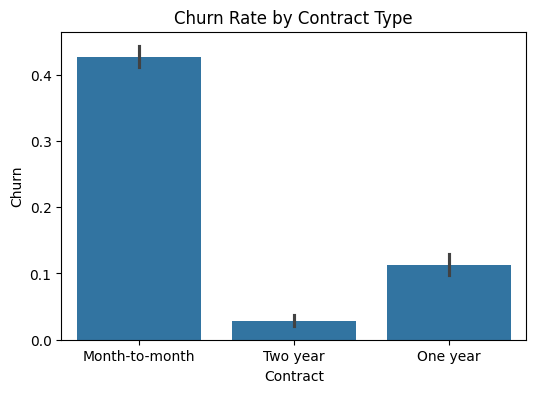

In [21]:
plt.figure(figsize=(6,4))
sns.barplot(x='Contract', y='Churn', data=df)
plt.title("Churn Rate by Contract Type")
plt.show()


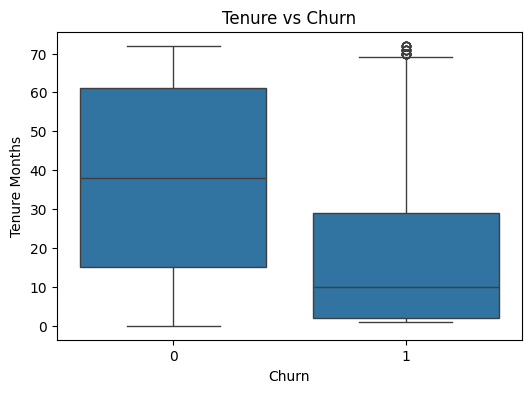

In [22]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='Tenure Months', data=df)
plt.title("Tenure vs Churn")
plt.show()


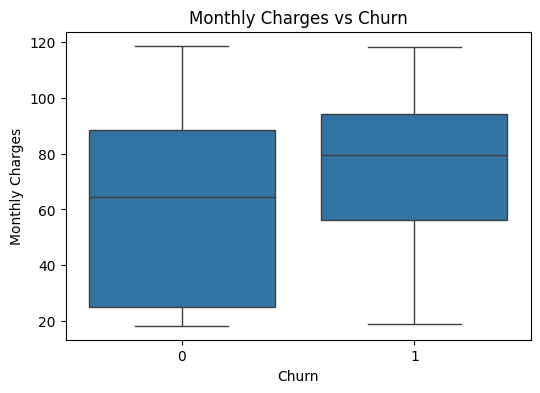

In [23]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='Monthly Charges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()


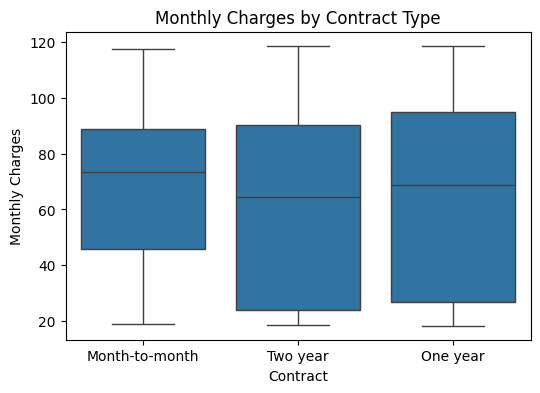

In [24]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Contract', y='Monthly Charges', data=df)
plt.title("Monthly Charges by Contract Type")
plt.show()


In [25]:
# converting categorical columns into numeric form
# model cannot understand text values like "Yes", "Male", etc.

df_encoded = pd.get_dummies(df, drop_first=True)

# checking first few rows after encoding
df_encoded.head()


,Count,Tenure Months,Monthly Charges,Churn,Churn Score,CLTV,City_Acton,City_Adelanto,City_Adin,City_Agoura Hills,...,Total Charges_8529.5,Total Charges_8543.25,Total Charges_8547.15,Total Charges_8564.75,Total Charges_8594.4,Total Charges_8670.1,Total Charges_8672.45,Total Charges_8684.8,Total Charges_,Churn Label_Yes
0,1,2,53.85,1,86,3239,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,1,2,70.70,1,67,2701,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,1,8,99.65,1,86,5372,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,1,28,104.80,1,84,5003,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,1,49,103.70,1,89,5340,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True


In [26]:
# checking new shape after encoding
df_encoded.shape


(7043, 7692)

In [27]:
# checking number of unique values in each column
df.nunique().sort_values(ascending=False).head(10)


Total Charges       6531
CLTV                3438
Monthly Charges     1585
City                1129
Churn Score           85
Tenure Months         73
Payment Method         4
Online Security        3
Online Backup          3
Internet Service       3
dtype: int64

In [28]:
# removing columns that are not useful for modeling
df_model = df.drop(['City', 'CLTV', 'Churn Score'], axis=1)

# checking shape after dropping
df_model.shape


(7043, 24)

In [29]:
# converting only categorical columns into numeric
df_encoded = pd.get_dummies(df_model, drop_first=True)

# checking new shape
df_encoded.shape


(7043, 6562)

In [30]:
df.dtypes


Count                  int64
Country               object
State                 object
City                  object
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges         object
Churn Label           object
Churn                  int64
Churn Score            int64
CLTV                   int64
dtype: object

In [31]:
# converting Total Charges to numeric properly
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')


In [32]:
df.dtypes


Count                  int64
Country               object
State                 object
City                  object
Gender                object
Senior Citizen        object
Partner               object
Dependents            object
Tenure Months          int64
Phone Service         object
Multiple Lines        object
Internet Service      object
Online Security       object
Online Backup         object
Device Protection     object
Tech Support          object
Streaming TV          object
Streaming Movies      object
Contract              object
Paperless Billing     object
Payment Method        object
Monthly Charges      float64
Total Charges        float64
Churn Label           object
Churn                  int64
Churn Score            int64
CLTV                   int64
dtype: object

In [33]:
# selecting only object (categorical) columns
categorical_cols = df.select_dtypes(include=['object']).columns

categorical_cols


Index(['Country', 'State', 'City', 'Gender', 'Senior Citizen', 'Partner',
       'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Churn Label'],
      dtype='object')

In [34]:
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

df_encoded.shape


(7043, 1163)

In [36]:
df.columns


Index(['Count', 'Country', 'State', 'City', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn',
       'Churn Score', 'CLTV'],
      dtype='object')

In [50]:
df_model.columns


Index(['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months',
       'Phone Service', 'Multiple Lines', 'Internet Service',
       'Online Security', 'Online Backup', 'Device Protection', 'Tech Support',
       'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing',
       'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label',
       'Churn'],
      dtype='object')

In [51]:
df_model = df_model.drop('Churn Label', axis=1)


In [52]:
# selecting only categorical (text) columns
categorical_cols = df_model.select_dtypes(include=['object']).columns

# converting those into numeric using one-hot encoding
df_encoded = pd.get_dummies(df_model, columns=categorical_cols, drop_first=True)

# checking final shape
df_encoded.shape

(7043, 31)

In [53]:
# removing rows where Total Charges is missing
df_encoded = df_encoded.dropna()

# checking new shape
df_encoded.shape


(7032, 31)

In [54]:
# separating features and target again
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']


In [55]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)


In [56]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [57]:
from sklearn.metrics import classification_report

y_pred = model.predict(X_test)

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1012
           1       0.70      0.58      0.63       395

    accuracy                           0.81      1407
   macro avg       0.77      0.74      0.75      1407
weighted avg       0.81      0.81      0.81      1407



In [58]:
from sklearn.linear_model import LogisticRegression

# giving more importance to minority class (churn)
model_balanced = LogisticRegression(max_iter=1000, class_weight='balanced')

model_balanced.fit(X_train, y_train)

y_pred_balanced = model_balanced.predict(X_test)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_balanced))


              precision    recall  f1-score   support

           0       0.91      0.73      0.81      1012
           1       0.54      0.81      0.65       395

    accuracy                           0.75      1407
   macro avg       0.73      0.77      0.73      1407
weighted avg       0.81      0.75      0.77      1407



C:\Users\harsh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:470: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [59]:
# getting feature importance from logistic regression

importance = pd.Series(
    model_balanced.coef_[0],
    index=X.columns
)

# sorting features by importance
importance_sorted = importance.sort_values()

# showing top 10 features that increase churn
importance_sorted.tail(10)


Total Charges                      0.000335
Monthly Charges                    0.015713
Streaming Movies_Yes               0.023940
Multiple Lines_Yes                 0.105306
Senior Citizen_Yes                 0.128379
Internet Service_Fiber optic       0.184662
Partner_Yes                        0.295476
Payment Method_Electronic check    0.304607
Paperless Billing_Yes              0.382464
Multiple Lines_No phone service    0.509244
dtype: float64